In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
from sklearn.metrics import auc
# load the dataset

data=pd.read_csv("/content/drive/MyDrive/MLPRO/alzheimers_disease_data.csv")
#data info used to see structure of the data

data_info=data.info()

#data.head is used to check the first 5 rows of dataset
#also we can pass argument in data.head to se how many rows as you want
data_head=data.head(15)#by defaut it will be 5 rows u can set as per your need
data_head #this used to see the value
#same variable to be used to print the data

print(data.shape)#used to know columns n rows
print(data.size)#size of data

data.describe()#used to now imp columns

data['Diagnosis'].value_counts()#total number of various types RECORDS

data.isnull().sum()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  2149 non-null   int64  
 1   Age                        2149 non-null   int64  
 2   Gender                     2149 non-null   int64  
 3   Ethnicity                  2149 non-null   int64  
 4   EducationLevel             2149 non-null   int64  
 5   BMI                        2149 non-null   float64
 6   Smoking                    2149 non-null   int64  
 7   AlcoholConsumption         2149 non-null   float64
 8   PhysicalActivity           2149 non-null   float64
 9   DietQuality                2149 non-null   float64
 10  SleepQuality               2149 non-null   float64
 11  FamilyHistoryAlzheimers    2149

,0
PatientID,0
Age,0
Gender,0
Ethnicity,0
EducationLevel,0
BMI,0
Smoking,0
AlcoholConsumption,0
PhysicalActivity,0
DietQuality,0


In [ ]:
from sklearn.feature_selection import mutual_info_classif

# Define categorical features
categorical_features = [
    'Gender', 'Ethnicity', 'EducationLevel', 'Smoking', 'AlcoholConsumption',
    'PhysicalActivity', 'DietQuality', 'MemoryComplaints',
    'BehavioralProblems', 'Confusion', 'Disorientation',
    'PersonalityChanges', 'DifficultyCompletingTasks', 'Forgetfulness'
]

# Prepare features and target using resampled data
X_cat_resampled = X_resampled[categorical_features]

# Calculate mutual information scores
mi_scores = mutual_info_classif(
    X_cat_resampled,
    y_resampled,
    discrete_features=True
)

mi_scores_dict = dict(zip(categorical_features, mi_scores))

# Sort and display
sorted_mi = sorted(mi_scores_dict.items(), key=lambda x: x[1], reverse=True)

print("Top Categorical Features Based on Mutual Information:")
for feature, score in sorted_mi:
    print(f"{feature}: {score:.4f}")

Top Categorical Features Based on Mutual Information:
AlcoholConsumption: 0.6931
PhysicalActivity: 0.6931
DietQuality: 0.6931
EducationLevel: 0.0966
Ethnicity: 0.0794
MemoryComplaints: 0.0684
Gender: 0.0375
BehavioralProblems: 0.0365
Smoking: 0.0324
Forgetfulness: 0.0305
Confusion: 0.0195
Disorientation: 0.0176
PersonalityChanges: 0.0167
DifficultyCompletingTasks: 0.0153


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.1

In [ ]:
from sklearn.feature_selection import mutual_info_classif

# Prepare features and target using resampled data
X_cat_resampled = X_resampled[categorical_features]
y_resampled = y_resampled

# Calculate mutual information scores
mi_scores = mutual_info_classif(X_cat_resampled, y_resampled, discrete_features=True)
mi_scores_dict = dict(zip(categorical_features, mi_scores))

top_categorical_features = sorted(mi_scores_dict, key=mi_scores_dict.get, reverse=True)[:5]
print("Top Categorical Features:", top_categorical_features)

Top Categorical Features: ['AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'EducationLevel', 'Ethnicity']


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.1

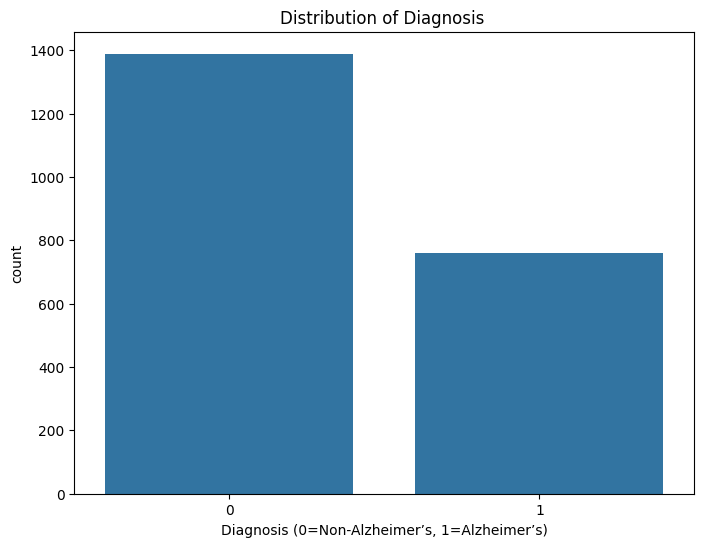

In [ ]:
# 4. Count Plot for distribution of 'TYPE'
plt.figure(figsize=(8, 6))
sns.countplot(x=y, data=data) # Using y for the diagnosis labels
plt.xlabel("Diagnosis (0=Non-Alzheimer’s, 1=Alzheimer’s)")
plt.title('Distribution of Diagnosis ')
plt.show()

In [ ]:
# Step 2: Handle Missing Values
# Separate numerical and categorical columns
numerical_features = ['Age', 'BMI', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality', 'SystolicBP', 'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment', 'ADL','Gender', 'Ethnicity', 'EducationLevel', 'Smoking', 'FamilyHistoryAlzheimers', 'CardiovascularDisease', 'Diabetes', 'Depression', 'HeadInjury', 'Hypertension', 'MemoryComplaints', 'BehavioralProblems', 'Confusion', 'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks', 'Forgetfulness','XXXConfid']

categorical_features = ['Diagnosis','DoctorInCharge']

# Ensure 'XXXConfid' is removed from numerical_features before imputation and scaling
if 'XXXConfid' in numerical_features:
    numerical_features.remove('XXXConfid')  # Remove the problematic column

#imput
numerical_imputer=SimpleImputer(strategy='most_frequent')
# Impute only on the selected numerical features, excluding 'XXXConfid'
data[numerical_features]=numerical_imputer.fit_transform(data[numerical_features])




# Impute missing values for categorical data with the most frequent value
categorical_imputer = SimpleImputer(strategy='most_frequent')
data[categorical_features] = categorical_imputer.fit_transform(data[categorical_features])



# Step 3: Normalize or Standardize Numerical Features
scaler = StandardScaler()
# drop_columns is not needed anymore since 'XXXConfid' is removed from numerical_features
drop_columns = ['XXXConfid']
data[numerical_features] = scaler.fit_transform(data[numerical_features])

In [ ]:
from sklearn.preprocessing import OneHotEncoder

# OneHotEncoder to convert categorical 'TYPE' into numeric binary columns
encoder = OneHotEncoder(sparse_output=False)  # sparse_output is used instead of sparse
encoded_categorical_data = encoder.fit_transform(data[categorical_features])

KeyError: "None of [Index(['Diagnosis', 'DoctorInCharge'], dtype='object')] are in the [columns]"

In [ ]:
encoded_categorical_df = pd.DataFrame(encoded_categorical_data, columns=encoder.get_feature_names_out())
data = data.drop(categorical_features, axis=1)  # Note: axis=1 to drop columns
data = pd.concat([data, encoded_categorical_df], axis=1)

In [ ]:
# Prepare X and y for the model
X = data.drop(encoded_categorical_df.columns, axis=1)
y = encoded_categorical_df.values.argmax(axis=1)  # This gives classes like 0, 1, 2, etc. for TYPE

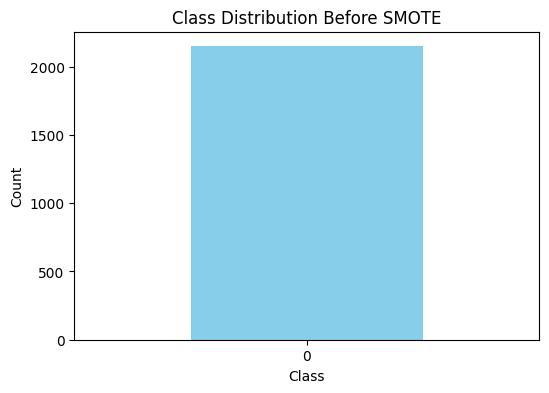

In [ ]:
# Count original class distribution
before_counts = pd.Series(y).value_counts()

# Plot before SMOTE
plt.figure(figsize=(6,4))
before_counts.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title("Class Distribution Before SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

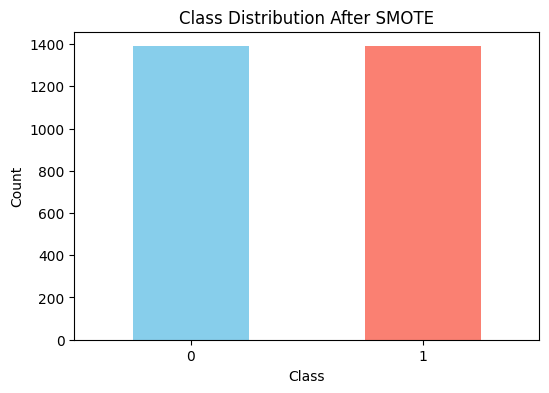

In [ ]:
from collections import Counter
# Split features and target
X = X_resampled
y = y_resampled

# Apply SMOTE - SMOTE is already applied in the previous step
# sm = SMOTE(random_state=42)
# X_res, y_res = sm.fit_resample(X, y)

# Count after SMOTE
after_counts = pd.Series(Counter(y_resampled))

# Plot after SMOTE
plt.figure(figsize=(6,4))
after_counts.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title("Class Distribution After SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [ ]:
from imblearn.over_sampling import SMOTE
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

# 1. Separate target variable (y) and features (X)
y = data['Diagnosis']
X = data.drop(['PatientID', 'Diagnosis'], axis=1)

# 2. Identify numerical and categorical features within X
# All int64 columns (except PatientID and Diagnosis which are dropped) and float64 columns are treated as numerical for scaling
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

# DoctorInCharge is the only object type column left, treat as categorical
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()


# Impute missing values for numerical data with the most frequent value (though info showed no missing values)
numerical_imputer=SimpleImputer(strategy='most_frequent')
X[numerical_features]=numerical_imputer.fit_transform(X[numerical_features])

# Impute missing values for categorical data (only DoctorInCharge) with the most frequent value
categorical_imputer = SimpleImputer(strategy='most_frequent')
if categorical_features: # Only impute if there are actual categorical features
    X[categorical_features] = categorical_imputer.fit_transform(X[categorical_features])

# 3. Normalize or Standardize Numerical Features
scaler = StandardScaler()
X[numerical_features] = scaler.fit_transform(X[numerical_features])

# 4. Encode Categorical Features
if categorical_features: # Only encode if there are actual categorical features
    encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore') # handle_unknown to prevent errors if new categories appear
    encoded_categorical_data = encoder.fit_transform(X[categorical_features])
    encoded_categorical_df = pd.DataFrame(encoded_categorical_data, columns=encoder.get_feature_names_out(categorical_features))

    # Drop original categorical columns from X and concatenate encoded ones
    X = X.drop(categorical_features, axis=1)
    X = pd.concat([X, encoded_categorical_df], axis=1)

# 5. Apply SMOTE to handle class imbalance
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Check the distribution after applying SMOTE
print("Original dataset class distribution:\n", pd.Series(y).value_counts())
print("Resampled dataset class distribution:\n", pd.Series(y_resampled).value_counts())

KeyError: 'Diagnosis'

In [ ]:
# Step 6: Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

KNN Accuracy: 74.28%
Loss (1 - accuracy): 0.2572

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.59      0.69       273
           1       0.69      0.89      0.78       283

    accuracy                           0.74       556
   macro avg       0.77      0.74      0.74       556
weighted avg       0.76      0.74      0.74       556


Confusion Matrix:
[[161 112]
 [ 31 252]]


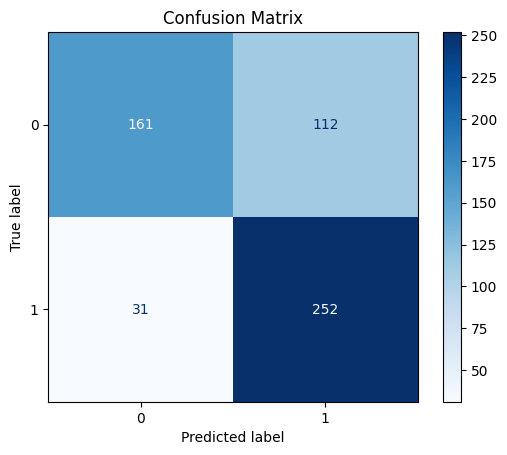

In [ ]:
# Step 6: Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Step 7: Build KNN Model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Step 8: Model Evaluation
# Predict the test set
y_pred = knn.predict(X_test)

# Compute accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"KNN Accuracy: {accuracy * 100:.2f}%")
# Compute loss as (1 - accuracy)
loss = 1 - accuracy
print(f"Loss (1 - accuracy): {loss:.4f}")

# Classification Report
print("\nClassification Report:")
# Use unique values from y_test as target names
target_names = [str(label) for label in np.unique(y_test)]
print(classification_report(y_test, y_pred, target_names=target_names))

# Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Plot Confusion Matrix using ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_test))
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
# Step 7: Build Random Forest Model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Step 8: Model Evaluation
# Predict the test set
y_pred = rf.predict(X_test)

# Compute accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Random Forest Accuracy: {accuracy * 100:.2f}%")
# Compute loss as (1 - accuracy)
loss = 1 - accuracy
print(f"Loss (1 - accuracy): {loss:.4f}")

# Classification Report
print("\nClassification Report:")
# Convert encoder.categories_[0] to a list of strings
target_names = [str(name) for name in encoder.categories_[0]]
print(classification_report(y_test, y_pred, target_names=target_names))


# Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Plot Confusion Matrix using ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=encoder.categories_[0])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# Step 7: Build Naive Bayes Model
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(X_train, y_train)

# Step 8: Model Evaluation
# Predict the test set
y_pred = nb.predict(X_test)

# Compute accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Naive Bayes Accuracy: {accuracy * 100:.2f}%")
# Compute loss as (1 - accuracy)
loss = 1 - accuracy
print(f"Loss (1 - accuracy): {loss:.4f}")

# Classification Report
print("\nClassification Report:")
# Convert encoder.categories_[0] to a list of strings
target_names = [str(name) for name in encoder.categories_[0]]
print(classification_report(y_test, y_pred, target_names=target_names))



# Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Plot Confusion Matrix using ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=encoder.categories_[0])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

In [ ]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression
# Step 7: Build Logistic Regression Model
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

# Step 8: Model Evaluation
# Predict the test set
y_pred = lr.predict(X_test)

# Compute accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Logistic Regression Accuracy: {accuracy * 100:.2f}%")
# Compute loss as (1 - accuracy)
loss = 1 - accuracy
print(f"Loss (1 - accuracy): {loss:.4f}")

# Classification Report
print("\nClassification Report:")
# Convert encoder.categories_[0] to a list of strings
target_names = [str(name) for name in encoder.categories_[0]]
print(classification_report(y_test, y_pred, target_names=target_names))

# Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Plot Confusion Matrix using ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=encoder.categories_[0])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

# Step 7: Build Hybrid Boost Model (Gradient Boosting)
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
gb.fit(X_train, y_train)

# Step 8: Model Evaluation
# Predict the test set
y_pred_gb = gb.predict(X_test)

# Compute accuracy
accuracy_gb = accuracy_score(y_test, y_pred_gb)
print(f"Gradient Boosting Accuracy: {accuracy_gb * 100:.2f}%")
# Compute loss as (1 - accuracy)
loss_gb = 1 - accuracy_gb
print(f"Loss (1 - accuracy): {loss_gb:.4f}")

# Classification Report
print("\nClassification Report:")
target_names = [str(name) for name in encoder.categories_[0]]
print(classification_report(y_test, y_pred_gb, target_names=target_names))

# Confusion Matrix
print("\nConfusion Matrix:")
cm_gb = confusion_matrix(y_test, y_pred_gb)
print(cm_gb)

# Plot Confusion Matrix using ConfusionMatrixDisplay
disp_gb = ConfusionMatrixDisplay(confusion_matrix=cm_gb, display_labels=encoder.categories_[0])
disp_gb.plot(cmap=plt.cm.Greens)
plt.title("Confusion Matrix - Gradient Boosting")
plt.show()


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:24:47] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 94.96%
Loss (1 - accuracy): 0.0504

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       273
           1       0.96      0.94      0.95       283

    accuracy                           0.95       556
   macro avg       0.95      0.95      0.95       556
weighted avg       0.95      0.95      0.95       556


Confusion Matrix:
[[263  10]
 [ 18 265]]


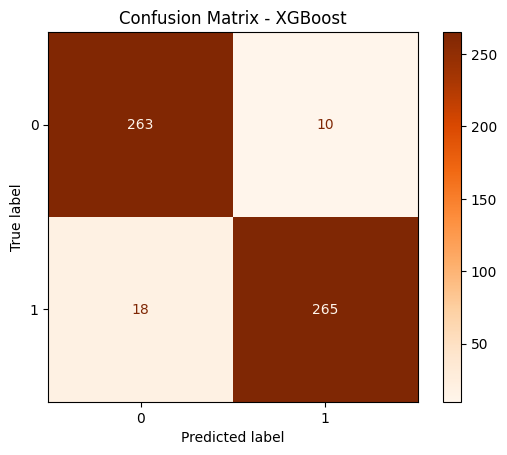

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np # Import numpy

# Step 7: Build XGBoost Model
xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'  # suppress warning for classification
)

xgb.fit(X_train, y_train)

# Step 8: Model Evaluation
# Predict the test set
y_pred_xgb = xgb.predict(X_test)

# Compute accuracy
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"XGBoost Accuracy: {accuracy_xgb * 100:.2f}%")

# Compute loss as (1 - accuracy)
loss_xgb = 1 - accuracy_xgb
print(f"Loss (1 - accuracy): {loss_xgb:.4f}")

# Classification Report
print("\nClassification Report:")
# Use unique values from y_test as target names
target_names = [str(label) for label in np.unique(y_test)]
print(classification_report(y_test, y_pred_xgb, target_names=target_names))

# Confusion Matrix
print("\nConfusion Matrix:")
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print(cm_xgb)

# Plot Confusion Matrix
# Use unique values from y_test as display labels
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=np.unique(y_test))
disp_xgb.plot(cmap=plt.cm.Oranges)
plt.title("Confusion Matrix - XGBoost")
plt.show()

Fitting 5 folds for each of 30 candidates, totalling 150 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:25:45] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ Best Parameters: {'colsample_bytree': np.float64(0.8469806697102145), 'learning_rate': np.float64(0.11207349717527182), 'max_depth': 8, 'n_estimators': 237, 'subsample': np.float64(0.9400846854395364)}

🎯 XGBoost Accuracy (after tuning): 95.68%
❌ Loss (1 - accuracy): 0.0432

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       273
           1       0.98      0.94      0.96       283

    accuracy                           0.96       556
   macro avg       0.96      0.96      0.96       556
weighted avg       0.96      0.96      0.96       556


🧩 Confusion Matrix:
 [[267   6]
 [ 18 265]]


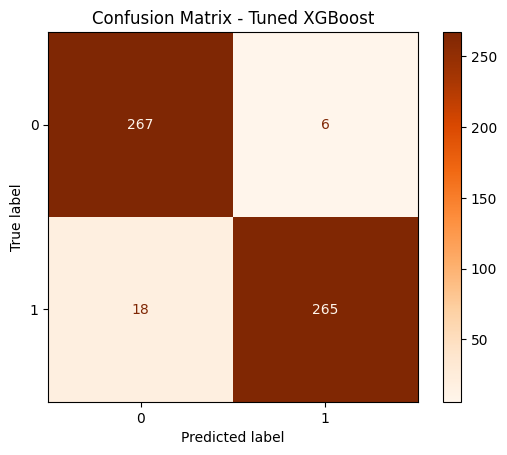

In [ ]:
from xgboost import XGBClassifier, plot_importance
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
import matplotlib.pyplot as plt
import numpy as np # Import numpy

# Step 1: Set up hyperparameter search space
param_dist = {
    'n_estimators': randint(100, 300),
    'learning_rate': uniform(0.01, 0.3),
    'max_depth': randint(3, 10),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4)
}

# Step 2: Set up RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    param_distributions=param_dist,
    n_iter=30,
    scoring='accuracy',
    cv=5,
    verbose=1,
    n_jobs=-1
)

# Step 3: Fit the model using randomized search
random_search.fit(X_train, y_train)
best_model = random_search.best_estimator_
print("✅ Best Parameters:", random_search.best_params_)

# Step 4: Predict and Evaluate
y_pred_xgb = best_model.predict(X_test)

# Accuracy
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"\n🎯 XGBoost Accuracy (after tuning): {accuracy_xgb * 100:.2f}%")

# Loss
loss_xgb = 1 - accuracy_xgb
print(f"❌ Loss (1 - accuracy): {loss_xgb:.4f}")

# Classification Report
print("\n📊 Classification Report:")
# Use unique values from y_test as target names
target_names = [str(label) for label in np.unique(y_test)]
print(classification_report(y_test, y_pred_xgb, target_names=target_names))

# Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print("\n🧩 Confusion Matrix:\n", cm_xgb)

disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=np.unique(y_test))
disp_xgb.plot(cmap=plt.cm.Oranges)
plt.title("Confusion Matrix - Tuned XGBoost")
plt.show()

Best Parameters: {'colsample_bytree': np.float64(0.8469806697102145), 'learning_rate': np.float64(0.11207349717527182), 'max_depth': 8, 'n_estimators': 237, 'subsample': np.float64(0.9400846854395364)}


/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [09:13:39] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


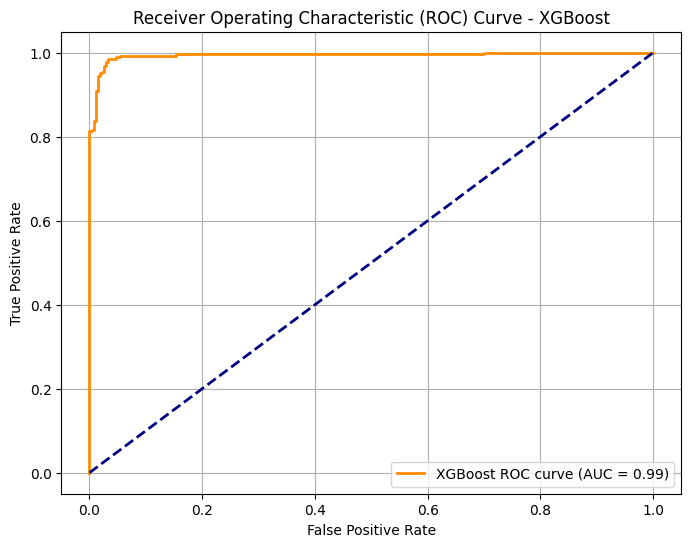

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
# from sklearn.model_selection import train_test_split # Already imported and used
# from sklearn.preprocessing import StandardScaler # Already imported and used
import matplotlib.pyplot as plt
import numpy as np # Import numpy

# Assuming your features and target are already split and scaled
# X_train, X_test, y_train, y_test are available from previous steps

# Train XGBoost model using the existing split data
model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
model.fit(X_train, y_train)

# Predict probabilities on the test set
y_probs = model.predict_proba(X_test)[:, 1]

# ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'XGBoost ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - XGBoost')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [ ]:
#FOR AWS HACKATHON
best_model = random_search.best_estimator_
print("Best Parameters:", random_search.best_params_)

Best Parameters: {'colsample_bytree': np.float64(0.8469806697102145), 'learning_rate': np.float64(0.11207349717527182), 'max_depth': 8, 'n_estimators': 237, 'subsample': np.float64(0.9400846854395364)}


In [ ]:
import joblib
joblib.dump(best_model, "xgboost_model.joblib")

['xgboost_model.joblib']

In [ ]:
from google.colab import files
files.download("xgboost_model.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
best_model.save_model("model.json")

In [ ]:
from google.colab import files
files.download("model.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print(X.shape)

(2778, 33)


In [ ]:
print(X.columns)

Index(['Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI', 'Smoking',
       'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality',
       'FamilyHistoryAlzheimers', 'CardiovascularDisease', 'Diabetes',
       'Depression', 'HeadInjury', 'Hypertension', 'SystolicBP', 'DiastolicBP',
       'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL',
       'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment',
       'MemoryComplaints', 'BehavioralProblems', 'ADL', 'Confusion',
       'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks',
       'Forgetfulness', 'DoctorInCharge_XXXConfid'],
      dtype='object')


In [ ]:
negative_sample = X[y == 0].iloc[0].values.tolist()
print(negative_sample)

[-0.21236841460796366, -1.0126439111838286, -0.7004082570105744, 0.7888334816806862, -0.6552253078749699, -0.6367839404293663, 0.565923067600845, 0.49252490501791346, -1.2535934136218392, 1.1199180491702425, -0.5807533249093624, -0.4105726183417841, 2.3733343736993144, 1.9965166882124739, -0.31945466353033897, -0.4182809988342581, 0.2981587366231379, -1.0147502679511324, 0.40367690612845963, -1.5726605758307495, -1.1144291597353106, -0.6481994462194258, 0.77903679272318, 0.4975058788471379, -0.5124765335259812, -0.43125669844751385, -1.1044344862722253, -0.5081306144206186, -0.4335310175443318, -0.42134812990607007, 2.302618680095285, -0.6570480894668862, 1.0]
